# 01 - Exploratory Data Analysis

Profiling and statistics over the processed tables with PySpark, then the EDA
charts that motivate the modelling. Run the ingest + process stages first (or
`python -m tools.make_sample` for the sample).

In [1]:
import sys
sys.path.append('..')
from src.common import get_spark, load_config, project_path
from pyspark.sql import functions as F

cfg = load_config()
spark = get_spark('eda')
pq = project_path(cfg['paths']['parquet'])
trip = spark.read.parquet(str(pq / 'fact_trip_delay'))
rbd = spark.read.parquet(str(pq / 'fact_route_band_day'))
print('trips', trip.count(), '| route-band-days', rbd.count())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/10 07:59:09 WARN Utils: Your hostname, Bishowdips-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.72 instead (on interface en0)
26/07/10 07:59:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/10 07:59:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


trips 87896 | route-band-days 9533


## Profiling: nulls, cardinality, describe

In [2]:
trip.describe(['median_delay', 'stops_observed']).show()
rbd.select(
    F.approx_count_distinct('route_id').alias('routes'),
    F.approx_count_distinct('time_band').alias('bands'),
    F.sum(F.col('compliant')).alias('compliant_rows'),
    F.count('*').alias('rows'),
).show()

+-------+------------------+------------------+
|summary|      median_delay|    stops_observed|
+-------+------------------+------------------+
|  count|             87896|             87896|
|   mean|1.4501103576954586|19.100186584144897|
| stddev| 4.963102339374031|11.823318541503676|
|    min|             -59.9|                 1|
|    max|              59.0|               104|
+-------+------------------+------------------+



26/07/10 07:59:14 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------+-----+--------------+----+
|routes|bands|compliant_rows|rows|
+------+-----+--------------+----+
|   538|    4|          2557|9533|
+------+-----+--------------+----+



## Statistics the brief names: mean, median, std, skewness, kurtosis

In [3]:
trip.select(
    F.mean('median_delay').alias('mean'),
    F.expr('percentile_approx(median_delay, 0.5)').alias('median'),
    F.stddev('median_delay').alias('std'),
    F.skewness('median_delay').alias('skewness'),
    F.kurtosis('median_delay').alias('kurtosis'),
).show()

+------------------+------+-----------------+------------------+-----------------+
|              mean|median|              std|          skewness|         kurtosis|
+------------------+------+-----------------+------------------+-----------------+
|1.4501103576954586|  0.45|4.963102339374031|0.7701276278518997|34.35429739042909|
+------------------+------+-----------------+------------------+-----------------+



## Headline EDA chart: the long right tail of delay

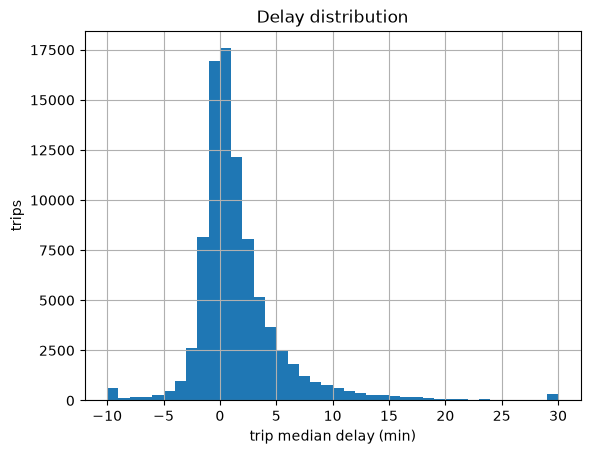

In [4]:
import matplotlib.pyplot as plt
pdf = trip.select('median_delay').toPandas()
pdf['median_delay'].clip(-10, 30).hist(bins=40)
plt.xlabel('trip median delay (min)'); plt.ylabel('trips'); plt.title('Delay distribution')
plt.show()

In [5]:
# on-time rate by time band
rbd.groupBy('time_band').agg(F.avg('pct_on_time').alias('on_time')).orderBy('on_time').show()

+----------+------------------+
| time_band|           on_time|
+----------+------------------+
|inter_peak|0.5239796214721077|
|   pm_peak|0.5790803610835892|
|   evening|0.6542379907459046|
|   am_peak|0.6627443577159332|
+----------+------------------+

